In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/deploypilot_ai_ci_cd_pipeline_dataset.csv")

In [3]:
failure_df = df[df["result"] == "FAIL"].copy()

print("Failure dataset shape:", failure_df.shape)

Failure dataset shape: (10000, 31)


In [4]:
print("Missing error messages:", failure_df["error_message"].isnull().sum())
print("Missing failure types:", failure_df["failure_type"].isnull().sum())

print("\nFailure type counts:")
print(failure_df["failure_type"].value_counts())

Missing error messages: 0
Missing failure types: 0

Failure type counts:
failure_type
Configuration Error      1000
Security Scan Failure    1000
Dependency Error         1000
Network Error            1000
Permission Error         1000
Resource Exhaustion      1000
Test Failure             1000
Deployment Failure       1000
Build Failure            1000
Timeout                  1000
Name: count, dtype: int64


In [5]:
import re

In [6]:
def clean_log(log_text):
    if log_text is None:
        return ""

    log_text = str(log_text).lower()

    log_text = re.sub(
        r"\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}",
        " ",
        log_text
    )

    log_text = re.sub(
        r"http[s]?://\S+",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"(\/[^\s]+)|([a-zA-Z]:\\[^\s]+)",
        " ",
        log_text
    )

    log_text = re.sub(
        r"0x[a-f0-9]+",
        " ",
        log_text
    )

    log_text = re.sub(
        r"<memory at .*?>",
        " memory_address ",
        log_text
    )

    log_text = re.sub(
        r"\b\d{5,}\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\b\d+\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"[^a-z\s]",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\s+",
        " ",
        log_text
    ).strip()

    return log_text

In [7]:
failure_df["cleaned_log"] = failure_df["error_message"].apply(clean_log)

In [8]:
print("Original log:")
print(failure_df["error_message"].iloc[0])

print("\nCleaned log:")
print(failure_df["cleaned_log"].iloc[0])

Original log:
##[section]Starting: deploy | Agent job on Azure Pipelines | docker compose config | services.api.environment.SECRET_KEY contains an invalid reference; secret was not mounted in runner context

Cleaned log:
section starting deploy agent job on azure pipelines docker compose config services api environment secret key contains an invalid reference secret was not mounted in runner context


In [9]:
features = failure_df["cleaned_log"]
label = failure_df["failure_type"]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    features,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [12]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (8000,)
x_test shape: (2000,)
y_train shape: (8000,)
y_test shape: (2000,)


In [13]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
failure_type
Network Error            800
Configuration Error      800
Permission Error         800
Timeout                  800
Resource Exhaustion      800
Test Failure             800
Build Failure            800
Security Scan Failure    800
Deployment Failure       800
Dependency Error         800
Name: count, dtype: int64

Testing class distribution:
failure_type
Network Error            200
Permission Error         200
Deployment Failure       200
Dependency Error         200
Security Scan Failure    200
Test Failure             200
Configuration Error      200
Resource Exhaustion      200
Build Failure            200
Timeout                  200
Name: count, dtype: int64


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
tfidf = TfidfVectorizer(
    max_features=50,
    ngram_range=(1, 1),
    min_df=2
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("Training TF-IDF shape:", x_train_tfidf.shape)
print("Testing TF-IDF shape:", x_test_tfidf.shape)

Training TF-IDF shape: (8000, 50)
Testing TF-IDF shape: (2000, 50)


In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
model_lr = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42
)

model_lr.fit(x_train_tfidf, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, x_test_data, y_test_data):
    predictions = model.predict(x_test_data)

    print("Accuracy:", accuracy_score(y_test_data, predictions))
    print("Precision:", precision_score(y_test_data, predictions, average="macro"))
    print("Recall:", recall_score(y_test_data, predictions, average="macro"))
    print("Macro F1:", f1_score(y_test_data, predictions, average="macro"))
    print("Weighted F1:", f1_score(y_test_data, predictions, average="weighted"))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_data, predictions))

    print("\nClassification Report:")
    print(classification_report(y_test_data, predictions))

In [19]:
evaluate_model(model_lr, x_test_tfidf, y_test)

Accuracy: 0.8425
Precision: 0.8536090429812436
Recall: 0.8425
Macro F1: 0.8414990966841114
Weighted F1: 0.8414990966841113

Confusion Matrix:
[[198   0   0   0   0   0   0   0   0   2]
 [  5 175   0  18   0   0   0   0   0   2]
 [ 25   0 147   0   0   3   0   0  24   1]
 [  0   2   0 187   0   9   0   2   0   0]
 [  3   1   2   1 152   1   3  36   1   0]
 [  7   2   0   2  23 139   0  26   0   1]
 [ 15   2   0   0   0   0 156   0  24   3]
 [  6   1   2  20   0   5  11 154   0   1]
 [  0   0   3   0   0   0   0   0 194   3]
 [  0   3   1   0   0   1   2   0  10 183]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.76      0.99      0.86       200
  Configuration Error       0.94      0.88      0.91       200
     Dependency Error       0.95      0.73      0.83       200
   Deployment Failure       0.82      0.94      0.87       200
        Network Error       0.87      0.76      0.81       200
     Permission Error   

In [20]:
from sklearn.svm import LinearSVC

In [21]:
model_svm = LinearSVC(
    C=0.01,
    random_state=42
)

model_svm.fit(x_train_tfidf, y_train)

evaluate_model(model_svm, x_test_tfidf, y_test)

Accuracy: 0.8225
Precision: 0.847256020368043
Recall: 0.8225000000000001
Macro F1: 0.8216158418337007
Weighted F1: 0.8216158418337007

Confusion Matrix:
[[198   0   0   0   0   0   0   0   0   2]
 [ 12 159   0  27   0   0   0   0   0   2]
 [ 25   0 150   0   0   0   0   0  24   1]
 [  0   2   0 194   0   4   0   0   0   0]
 [  7   1   2   1 143   1   0  37   8   0]
 [  7   2   0   2  26 128   0  34   0   1]
 [ 31   1   0   0   0   0 139   0  26   3]
 [  7   1   2  25   0   1  10 153   0   1]
 [  0   0   1   0   0   0   0   0 196   3]
 [  2   1   0   0   0   0   0   0  12 185]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.69      0.99      0.81       200
  Configuration Error       0.95      0.80      0.87       200
     Dependency Error       0.97      0.75      0.85       200
   Deployment Failure       0.78      0.97      0.86       200
        Network Error       0.85      0.71      0.78       200
     Permissi

In [22]:
from sklearn.naive_bayes import MultinomialNB

In [23]:
model_nb = MultinomialNB()

model_nb.fit(x_train_tfidf, y_train)

evaluate_model(model_nb, x_test_tfidf, y_test)

Accuracy: 0.735
Precision: 0.7430689804969146
Recall: 0.7350000000000001
Macro F1: 0.7278321879668592
Weighted F1: 0.7278321879668592

Confusion Matrix:
[[193   1   0   0   0   0   4   0   0   2]
 [  3 157   0  17   0   0  21   0   0   2]
 [ 22   0 116   0   0  10   8  11  32   1]
 [  0   3   0 174   0  12   0  11   0   0]
 [ 10   2  18   9  89   0  22  36   0  14]
 [ 19  15   0   2  21 113   0  29   0   1]
 [ 16   2  14   0   0   0 133   0  30   5]
 [  8   8   3  13   4   8   8 147   0   1]
 [  0   0   3   0   0   0  11   0 183   3]
 [  0   4   0   1   0   4  14   0  12 165]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.71      0.96      0.82       200
  Configuration Error       0.82      0.79      0.80       200
     Dependency Error       0.75      0.58      0.66       200
   Deployment Failure       0.81      0.87      0.84       200
        Network Error       0.78      0.45      0.57       200
     Permissi

In [24]:
baseline_names = [
    "Logistic Regression",
    "Linear SVM",
    "Naive Bayes"
]

baseline_models = [
    model_lr,
    model_svm,
    model_nb
]

baseline_results = []

for model_name, current_model in zip(
    baseline_names,
    baseline_models
):
    predictions = current_model.predict(x_test_tfidf)

    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro"
        )
    })

In [25]:
baseline_comparison = pd.DataFrame(baseline_results)

baseline_comparison = baseline_comparison.sort_values(
    by="Macro F1",
    ascending=False
)

baseline_comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.8425,0.841499
1,Linear SVM,0.8225,0.821616
2,Naive Bayes,0.7350,0.727832


In [26]:
model_lr_v2 = LogisticRegression(
    C=0.5,
    max_iter=1000,
    random_state=42
)

model_lr_v2.fit(x_train_tfidf, y_train)

evaluate_model(model_lr_v2, x_test_tfidf, y_test)

Accuracy: 0.9035
Precision: 0.9094842504795617
Recall: 0.9035
Macro F1: 0.9034431070010946
Weighted F1: 0.9034431070010945

Confusion Matrix:
[[197   0   1   0   0   0   0   0   0   2]
 [  1 180   0  17   0   0   0   0   0   2]
 [ 25   0 161   0   0   1   0   0  12   1]
 [  0   2   0 189   0   2   0   7   0   0]
 [  0   0   3   2 169   0   0  26   0   0]
 [  2   2   1   2   0 192   0   0   0   1]
 [  2   2   0   0   0   0 169   0  24   3]
 [  5   1   1  20   0   1   8 163   0   1]
 [  0   0   3   0   0   0   0   0 194   3]
 [  0   2   2   0   0   0   0   0   3 193]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.85      0.98      0.91       200
  Configuration Error       0.95      0.90      0.93       200
     Dependency Error       0.94      0.81      0.87       200
   Deployment Failure       0.82      0.94      0.88       200
        Network Error       1.00      0.84      0.92       200
     Permission Error   

In [27]:
tfidf_v3 = TfidfVectorizer(
    max_features=60,
    ngram_range=(1, 1),
    min_df=2
)

x_train_tfidf_v3 = tfidf_v3.fit_transform(x_train)
x_test_tfidf_v3 = tfidf_v3.transform(x_test)

In [28]:
model_lr_v3 = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

model_lr_v3.fit(x_train_tfidf_v3, y_train)

evaluate_model(model_lr_v3, x_test_tfidf_v3, y_test)

Accuracy: 0.951
Precision: 0.9550805178333952
Recall: 0.951
Macro F1: 0.9509848727205565
Weighted F1: 0.9509848727205567

Confusion Matrix:
[[199   0   0   0   0   0   0   0   0   1]
 [  3 196   0   1   0   0   0   0   0   0]
 [ 10   0 189   0   0   0   0   0   0   1]
 [  0   2   0 197   0   0   0   1   0   0]
 [  0   1   0   2 195   0   0   0   0   2]
 [  3   2   0   3   0 191   0   0   0   1]
 [  2   2   0   0   0   0 169   0  25   2]
 [  4   1   0  21   0   0   0 174   0   0]
 [  0   0   0   0   0   0   0   0 196   4]
 [  0   3   0   0   0   0   0   0   1 196]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.90      0.99      0.95       200
  Configuration Error       0.95      0.98      0.96       200
     Dependency Error       1.00      0.94      0.97       200
   Deployment Failure       0.88      0.98      0.93       200
        Network Error       1.00      0.97      0.99       200
     Permission Error     

In [29]:
tfidf_v4 = TfidfVectorizer(
    max_features=70,
    ngram_range=(1, 1),
    min_df=2
)

x_train_tfidf_v4 = tfidf_v4.fit_transform(x_train)
x_test_tfidf_v4 = tfidf_v4.transform(x_test)

In [30]:
model_lr_v4 = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

model_lr_v4.fit(x_train_tfidf_v4, y_train)

evaluate_model(model_lr_v4, x_test_tfidf_v4, y_test)

Accuracy: 0.9705
Precision: 0.9717426625404464
Recall: 0.9705
Macro F1: 0.9706535382945607
Weighted F1: 0.9706535382945607

Confusion Matrix:
[[199   0   0   0   0   0   1   0   0   0]
 [  7 192   0   1   0   0   0   0   0   0]
 [  2   0 197   0   0   0   0   0   1   0]
 [  0   3   0 197   0   0   0   0   0   0]
 [  0   1   2   2 195   0   0   0   0   0]
 [  3   2   0   3   0 191   0   0   0   1]
 [  3   1   0   0   0   0 187   0   7   2]
 [  4   2   0   3   0   0   0 191   0   0]
 [  0   0   1   0   0   0   0   0 196   3]
 [  2   1   0   0   0   0   0   0   1 196]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.90      0.99      0.95       200
  Configuration Error       0.95      0.96      0.96       200
     Dependency Error       0.98      0.98      0.98       200
   Deployment Failure       0.96      0.98      0.97       200
        Network Error       1.00      0.97      0.99       200
     Permission Error   

In [31]:
tfidf_v5 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

x_train_tfidf_v5 = tfidf_v5.fit_transform(x_train)
x_test_tfidf_v5 = tfidf_v5.transform(x_test)

print("Final TF-IDF training shape:", x_train_tfidf_v5.shape)
print("Final TF-IDF testing shape:", x_test_tfidf_v5.shape)

Final TF-IDF training shape: (8000, 2149)
Final TF-IDF testing shape: (2000, 2149)


In [32]:
model_lr_v5 = LogisticRegression(
    C=0.1,
    max_iter=1000,
    random_state=42
)

model_lr_v5.fit(x_train_tfidf_v5, y_train)

evaluate_model(model_lr_v5, x_test_tfidf_v5, y_test)

Accuracy: 0.9725
Precision: 0.9742162662197659
Recall: 0.9724999999999999
Macro F1: 0.9727466672012858
Weighted F1: 0.9727466672012859

Confusion Matrix:
[[199   0   0   0   0   0   0   0   0   1]
 [  3 191   0   1   0   0   0   0   0   5]
 [  2   0 197   0   0   0   0   0   1   0]
 [  0   0   0 195   0   0   0   0   0   5]
 [  0   0   2   2 195   0   0   0   0   1]
 [  3   0   0   3   0 191   0   0   0   3]
 [  2   0   1   0   0   0 191   0   3   3]
 [  4   0   0   3   0   0   0 191   0   2]
 [  0   0   2   0   0   0   0   0 195   3]
 [  0   0   0   0   0   0   0   0   0 200]]

Classification Report:
                       precision    recall  f1-score   support

        Build Failure       0.93      0.99      0.96       200
  Configuration Error       1.00      0.95      0.98       200
     Dependency Error       0.98      0.98      0.98       200
   Deployment Failure       0.96      0.97      0.97       200
        Network Error       1.00      0.97      0.99       200
     Permiss

In [33]:
model_names = [
    "Logistic Regression Baseline",
    "Logistic Regression v2",
    "Logistic Regression v3",
    "Logistic Regression v4",
    "Logistic Regression v5"
]

models = [
    model_lr,
    model_lr_v2,
    model_lr_v3,
    model_lr_v4,
    model_lr_v5
]

test_data_list = [
    x_test_tfidf,
    x_test_tfidf,
    x_test_tfidf_v3,
    x_test_tfidf_v4,
    x_test_tfidf_v5
]

In [34]:
model_results = []

for model_name, current_model, current_test_data in zip(
    model_names,
    models,
    test_data_list
):
    predictions = current_model.predict(current_test_data)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average="macro"),
        "Recall": recall_score(y_test, predictions, average="macro"),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted")
    })

In [35]:
model_comparison = pd.DataFrame(model_results)
model_comparison

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Logistic Regression Baseline,0.8425,0.853609,0.8425,0.841499,0.841499
1,Logistic Regression v2,0.9035,0.909484,0.9035,0.903443,0.903443
2,Logistic Regression v3,0.9510,0.955081,0.9510,0.950985,0.950985
3,Logistic Regression v4,0.9705,0.971743,0.9705,0.970654,0.970654
4,Logistic Regression v5,0.9725,0.974216,0.9725,0.972747,0.972747


In [36]:
best_model = model_lr_v5
best_tfidf = tfidf_v5
best_model_name = "Logistic Regression v5"

print("Final selected model:", best_model_name)

Final selected model: Logistic Regression v5


In [37]:
final_predictions = best_model.predict(
    x_test_tfidf_v5
)

print("Final Accuracy:", accuracy_score(y_test, final_predictions))
print("Final Precision:", precision_score(y_test, final_predictions, average="macro"))
print("Final Recall:", recall_score(y_test, final_predictions, average="macro"))
print("Final Macro F1:", f1_score(y_test, final_predictions, average="macro"))
print("Final Weighted F1:", f1_score(y_test, final_predictions, average="weighted"))

Final Accuracy: 0.9725
Final Precision: 0.9742162662197659
Final Recall: 0.9724999999999999
Final Macro F1: 0.9727466672012858
Final Weighted F1: 0.9727466672012859


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

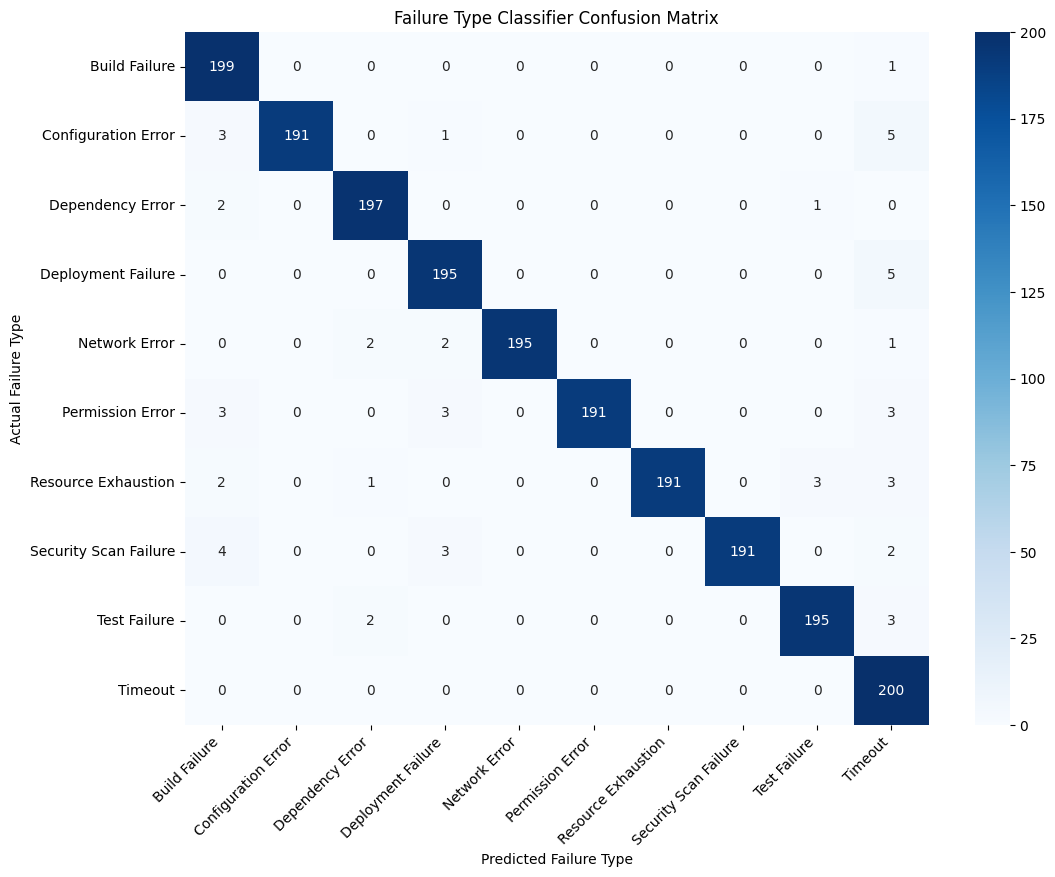

In [39]:
class_names = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=class_names
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Failure Type Classifier Confusion Matrix")
plt.xlabel("Predicted Failure Type")
plt.ylabel("Actual Failure Type")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [40]:
print(classification_report(
    y_test,
    final_predictions
))

                       precision    recall  f1-score   support

        Build Failure       0.93      0.99      0.96       200
  Configuration Error       1.00      0.95      0.98       200
     Dependency Error       0.98      0.98      0.98       200
   Deployment Failure       0.96      0.97      0.97       200
        Network Error       1.00      0.97      0.99       200
     Permission Error       1.00      0.95      0.98       200
  Resource Exhaustion       1.00      0.95      0.98       200
Security Scan Failure       1.00      0.95      0.98       200
         Test Failure       0.98      0.97      0.98       200
              Timeout       0.90      1.00      0.95       200

             accuracy                           0.97      2000
            macro avg       0.97      0.97      0.97      2000
         weighted avg       0.97      0.97      0.97      2000



In [41]:
import joblib
import json
import os

In [42]:
from sklearn.pipeline import Pipeline

In [43]:
final_model = Pipeline(steps=[
    ("tfidf", best_tfidf),
    ("model", best_model)
])

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_model,
    "../models/failure_type_classifier.pkl"
)

print("Failure type classifier saved successfully.")

Failure type classifier saved successfully.


In [44]:
failure_type_metrics = {
    "model_name": best_model_name,
    "accuracy": float(
        accuracy_score(y_test, final_predictions)
    ),
    "precision_macro": float(
        precision_score(
            y_test,
            final_predictions,
            average="macro"
        )
    ),
    "recall_macro": float(
        recall_score(
            y_test,
            final_predictions,
            average="macro"
        )
    ),
    "macro_f1": float(
        f1_score(
            y_test,
            final_predictions,
            average="macro"
        )
    ),
    "weighted_f1": float(
        f1_score(
            y_test,
            final_predictions,
            average="weighted"
        )
    ),
    "classes": int(
        failure_df["failure_type"].nunique()
    )
}

with open(
    "../models/failure_type_metrics.json",
    "w"
) as file:
    json.dump(
        failure_type_metrics,
        file,
        indent=4
    )

failure_type_metrics

{'model_name': 'Logistic Regression v5',
 'accuracy': 0.9725,
 'precision_macro': 0.9742162662197659,
 'recall_macro': 0.9724999999999999,
 'macro_f1': 0.9727466672012858,
 'weighted_f1': 0.9727466672012859,
 'classes': 10}

In [45]:
loaded_model = joblib.load(
    "../models/failure_type_classifier.pkl"
)

print("Final model loaded successfully.")
print("Model type:", type(loaded_model))

Final model loaded successfully.
Model type: <class 'sklearn.pipeline.Pipeline'>


In [46]:
validation_logs = [
    "AssertionError test expected 200 but received 500",
    "ModuleNotFoundError package dependency could not be installed",
    "Build failed compilation error cannot compile source code",
    "helm upgrade failed cannot patch deployment invalid image value",
    "Permission denied access forbidden while executing deployment",
    "Network connection refused unable to connect to remote server",
    "Configuration error missing environment variable DATABASE_URL",
    "Security scan failed critical vulnerability detected",
    "Out of memory process killed memory limit exceeded",
    "Operation timed out after waiting for service response"
]

expected_types = [
    "Test Failure",
    "Dependency Error",
    "Build Failure",
    "Deployment Failure",
    "Permission Error",
    "Network Error",
    "Configuration Error",
    "Security Scan Failure",
    "Resource Exhaustion",
    "Timeout"
]

In [47]:
cleaned_validation_logs = [
    clean_log(log)
    for log in validation_logs
]

predicted_types = loaded_model.predict(
    cleaned_validation_logs
)

correct_count = 0

for expected, predicted in zip(
    expected_types,
    predicted_types
):
    is_correct = expected == predicted

    if is_correct:
        correct_count += 1

    print("Expected:", expected)
    print("Predicted:", predicted)
    print("Correct:", is_correct)
    print("---")

print(
    "Correct validation predictions:",
    correct_count,
    "/",
    len(expected_types)
)

Expected: Test Failure
Predicted: Test Failure
Correct: True
---
Expected: Dependency Error
Predicted: Dependency Error
Correct: True
---
Expected: Build Failure
Predicted: Build Failure
Correct: True
---
Expected: Deployment Failure
Predicted: Deployment Failure
Correct: True
---
Expected: Permission Error
Predicted: Permission Error
Correct: True
---
Expected: Network Error
Predicted: Network Error
Correct: True
---
Expected: Configuration Error
Predicted: Configuration Error
Correct: True
---
Expected: Security Scan Failure
Predicted: Security Scan Failure
Correct: True
---
Expected: Resource Exhaustion
Predicted: Resource Exhaustion
Correct: True
---
Expected: Timeout
Predicted: Timeout
Correct: True
---
Correct validation predictions: 10 / 10
